# Import Libraries

In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Load Data

In [50]:
df = pd.read_csv(r"D:\Intership Tasks\customer-segmentation-ml\data\raw\Mall_Customers.csv")
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


# CREATE FOLDERS

In [51]:
os.makedirs("outputs/plots", exist_ok=True)
os.makedirs("outputs/reports", exist_ok=True)

# Basic Info

In [52]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


# Missing Values

In [53]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

# Gender Distribution

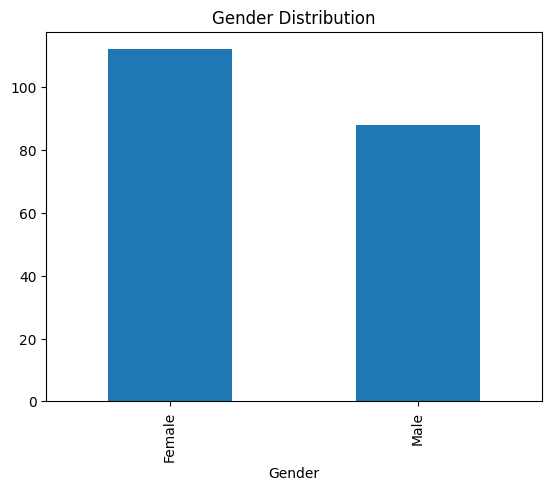

In [54]:
plt.figure()

df['Gender'].value_counts().plot(kind='bar')
plt.title("Gender Distribution")

plt.savefig("outputs/plots/gender_distribution.png", dpi=300)
plt.show()

# Age Distribution

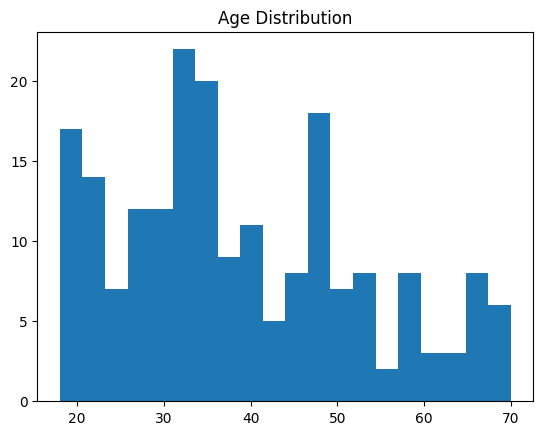

In [55]:
plt.figure()

plt.hist(df['Age'], bins=20)
plt.title("Age Distribution")

plt.savefig("outputs/plots/age_distribution.png", dpi=300)
plt.show()

# Income vs Spending Score

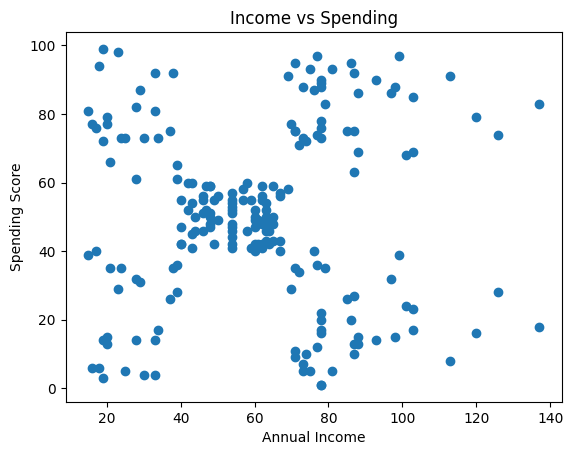

In [56]:
plt.figure()

plt.scatter(df['Annual Income (k$)'], df['Spending Score (1-100)'])
plt.xlabel("Annual Income")
plt.ylabel("Spending Score")
plt.title("Income vs Spending")

plt.savefig("outputs/plots/income_vs_spending.png", dpi=300)
plt.show()

# Correlation Heatmap

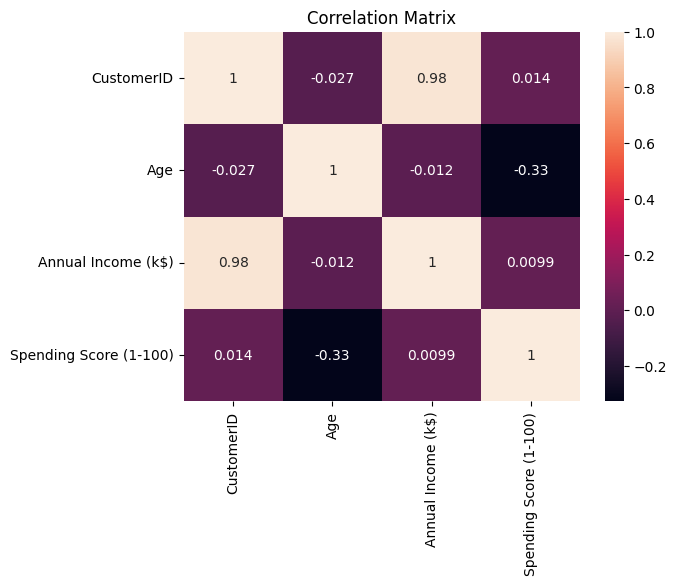

In [57]:
plt.figure()

numeric_df = df.select_dtypes(include=['int64', 'float64'])

sns.heatmap(numeric_df.corr(), annot=True)
plt.title("Correlation Matrix")

plt.savefig("outputs/plots/correlation_matrix.png", dpi=300)
plt.show()

# REPORT CREATE

report = """
CUSTOMER SEGMENTATION EDA REPORT

1. Dataset Overview:
- Contains customer demographic and spending data
- No missing values found

2. Key Insights:
- Age distribution is varied
- Income and spending are not directly correlated
- Different customer behavior patterns exist

3. Business Value:
- Helps in targeted marketing
- Improves customer segmentation strategy
- Identifies high-value customers

4. Techniques Used:
- Exploratory Data Analysis
- Data Visualization
- Correlation Analysis
"""

with open("outputs/reports/eda_report.txt", "w") as f:
    f.write(report)